In [1]:
# plot graph or chart
import matplotlib.pyplot as plt
import pandas as pd
# metrics
from sklearn.metrics import (
	accuracy_score,
	precision_score,
	recall_score,
	f1_score
)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from xgboost import XGBClassifier

In [2]:
df = pd.read_csv("../data/raw/online_shoppers_intention.csv")

df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


Convert "Revenue" to int (0 or 1)

In [3]:
df["Revenue"] = df["Revenue"].astype(int)

Splitting the Data

In [4]:
X = df.drop("Revenue", axis=1)
y = df["Revenue"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
	X,
	y,
	test_size=0.2,
	random_state=42,
	stratify=y
)

Categorical Features

In [6]:
categorical_features = [
	"Month",
	"VisitorType",
	"Weekend"
]

ColumnTransformer

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
	transformers=[
		(
			"cat",
			OneHotEncoder(handle_unknown="ignore"),
			categorical_features
		)
	],
	remainder="passthrough"
)

Transform

In [8]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

## Training 1 - XGBoost Classifier (Baseline)

Start settings XGBoost Classifier

In [57]:
model = XGBClassifier(
	random_state=42,
	eval_metric="logloss"
)

In [58]:
model.fit(
	X_train_processed,
	y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

Prediction

In [59]:
y_pred = model.predict(
	X_test_processed
)

## Training 2 - XGBoost Classifier (Optimizing Hyperparameters)

New XGBoost Model - Second round training

In [9]:
xgb = XGBClassifier(
	objective="binary:logistic",
	eval_metric="logloss",
	random_state=42
)

Fix class imbalance issue with scale_pos_weight parameter

In [10]:
scale_pos_weight = (
		y_train.value_counts()[0] /
		y_train.value_counts()[1]
)

param_dist = {
	"n_estimators": [100, 200, 300],
	"max_depth": [3, 5, 7],
	"learning_rate": [0.01, 0.05, 0.1],
	"subsample": [0.8, 1.0],
	"colsample_bytree": [0.8, 1.0],
	"min_child_weight": [1, 3, 5],
	"gamma": [0, 0.1, 0.3],
	"scale_pos_weight": [scale_pos_weight]
}

random_search = RandomizedSearchCV(
	estimator=xgb,
	param_distributions=param_dist,
	n_iter=30,
	scoring="f1",
	cv=5,
	verbose=2,
	random_state=42,
	n_jobs=-1
)

Fit the model to the training data

In [11]:
random_search.fit(X_train_processed, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_const...
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 1.0],
                                        'gamma': [0, 0.1, 0.3],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 5, 7],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [100, 200, 300],
                                        'scale_pos_weight': [5.463958060288335],
                                        'subsample': [0.8, 1.0]},
                   random_state=42, scoring='f1', verbose=2)

Print output

In [12]:
print(random_search.best_params_)
print(random_search.best_score_)
print(random_search.best_estimator_)

{'subsample': 1.0, 'scale_pos_weight': 5.463958060288335, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 7, 'learning_rate': 0.1, 'gamma': 0.3, 'colsample_bytree': 0.8}
0.676717172168851
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0.3,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)


Optimized Model Evaluation

In [13]:
best_model = random_search.best_estimator_

y_pred = best_model.predict(X_test_processed)

y_prob = best_model.predict_proba(X_test_processed)[:, 1]

In [17]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

print(roc_auc)

0.9231278451628463


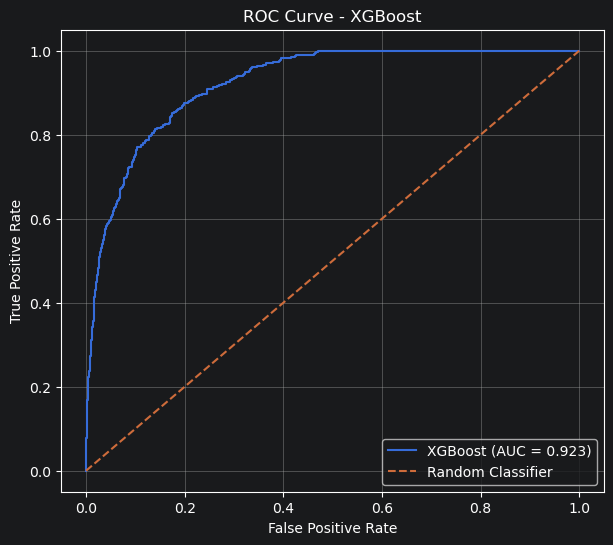

In [18]:
plt.figure(figsize=(7, 6))

plt.plot(
	fpr,
	tpr,
	label=f"XGBoost (AUC = {roc_auc:.3f})"
)

plt.plot(
	[0, 1],
	[0, 1],
	linestyle="--",
	label="Random Classifier"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - XGBoost")

plt.legend()

plt.grid(True)

plt.show()

## Model Evaluation

In [14]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1 :", f1_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy : 0.8791565287915653
Precision: 0.5893617021276596
Recall : 0.725130890052356
F1 : 0.6502347417840375
              precision    recall  f1-score   support

           0       0.95      0.91      0.93      2084
           1       0.59      0.73      0.65       382

    accuracy                           0.88      2466
   macro avg       0.77      0.82      0.79      2466
weighted avg       0.89      0.88      0.88      2466



Confusion Matrix (CLI version)

In [15]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1891  193]
 [ 105  277]]


Confusion Matrix (GUI version)

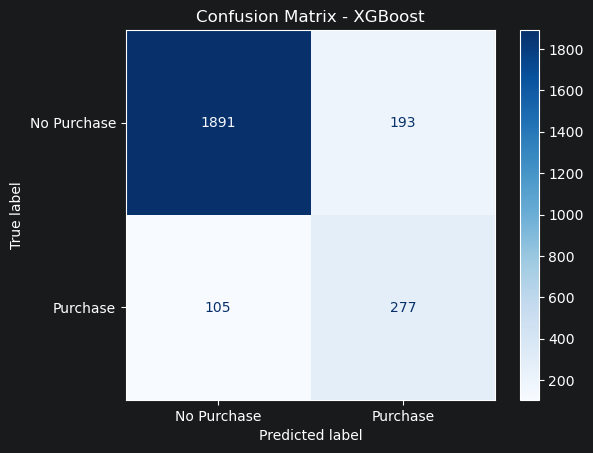

In [16]:
disp = ConfusionMatrixDisplay(
	confusion_matrix=cm,
	display_labels=["No Purchase", "Purchase"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - XGBoost")
plt.show()

Features importance

In [64]:
feature_names = preprocessor.get_feature_names_out()

# Feature Importance
importance = model.feature_importances_

importance_df = pd.DataFrame({
	"Feature": feature_names,
	"Importance": importance
}).sort_values(by="Importance", ascending=False)

print(importance_df.tail(15))

                               Feature  Importance
16  remainder__Administrative_Duration    0.021593
10        cat__VisitorType_New_Visitor    0.021015
13                  cat__Weekend_False    0.020927
22                remainder__ExitRates    0.020864
18   remainder__Informational_Duration    0.020391
28              remainder__TrafficType    0.019238
17            remainder__Informational    0.017837
25         remainder__OperatingSystems    0.017347
27                   remainder__Region    0.016304
24               remainder__SpecialDay    0.016008
26                  remainder__Browser    0.014493
4                      cat__Month_June    0.014076
2                       cat__Month_Feb    0.013585
11              cat__VisitorType_Other    0.002268
14                   cat__Weekend_True    0.000000


Plot a diagram of the top 15 feature importance

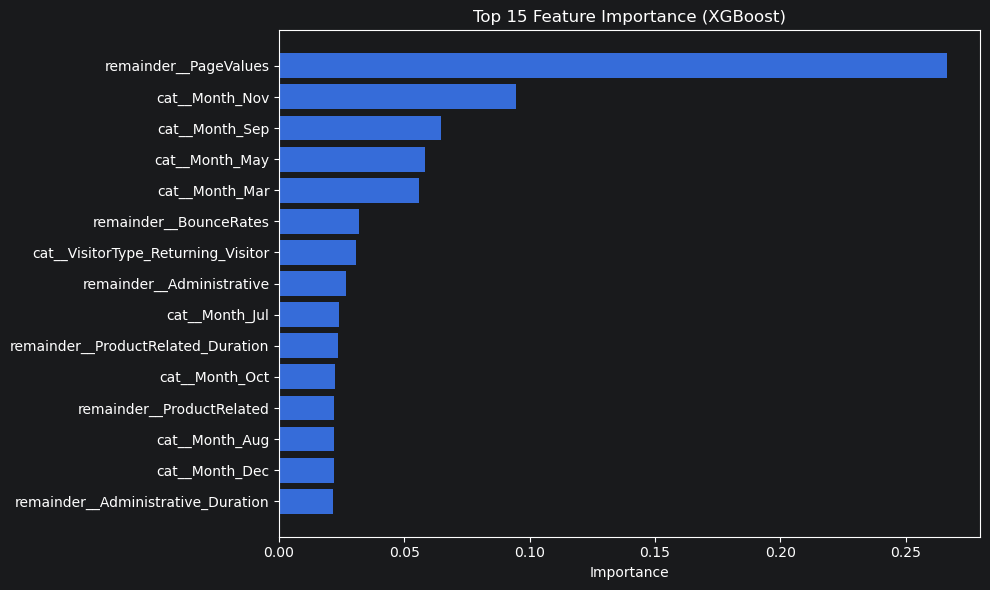

In [65]:
plt.figure(figsize=(10, 6))

plt.barh(
	importance_df["Feature"][:15][::-1],
	importance_df["Importance"][:15][::-1]
)

plt.xlabel("Importance")
plt.title("Top 15 Feature Importance (XGBoost)")
plt.tight_layout()
plt.show()

Checking
before
training
model

In [66]:
import xgboost
import sklearn

print("XGBoost:", xgboost.__version__)
print("Scikit-learn:", sklearn.__version__)

XGBoost: 3.3.0
Scikit-learn: 1.5.1


Test

In [33]:
print(y_train.value_counts())

print(y_train.unique())

Revenue
0    8338
1    1526
Name: count, dtype: int64
[0 1]
